# Imports & Paths

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback.
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

from cnt_project.io.paths import ProjectPaths
from src.data.confusion_metrics import load_confusion_metrics
from src.utils.paths import OUTPUTS
from src.utils.constants import (
    F1_NAME_MAP,
    COLOR_MAP,
    F1_LEGEND_ORDER,
    FIG_SIZES,
)

from cnt_project.visualizations.experiments.paper_figures.f1_curves import (
    plot_f1_iou_curves,
)

P = ProjectPaths.from_here(PROJECT_ROOT / "src" / "cnt_project" / "io" / "paths.py")
print(f"Using runs root: {P.runs_root}")

Using runs root: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs


# Define model list & metric file

In [2]:
metric_file = "dsb_per_image_threshold_metrics.csv"

model_names = [
    'fluo_new_edt',
    'detectron2_trial_1',
    'wormswin',
    'nano1D',
]


# Load all confusion metrics

In [3]:
conf_df = load_confusion_metrics(
    model_names=model_names,
    project_paths=P,
    metric_file=metric_file,
)

# Map readable model names (NanoVision, WormSwin, etc.)
conf_df["experiment"] = conf_df["experiment"].map(
    lambda x: F1_NAME_MAP.get(x, x)
)

# EXCLUDE Nano1D exactly like original notebook
conf_df = conf_df[conf_df["experiment"] != "Nano1D"]

conf_df.head()


,image_id,IoU_thresh,TP,FP,FN,avg_dice,precision,experiment
0,1293-22_3_2_20230306222551,0.00,96,75,8,0.477829,0.536313,NanoVision
1,1293-22_3_2_20230306222551,0.05,96,75,8,0.477829,0.536313,NanoVision
2,1293-22_3_2_20230306222551,0.10,95,76,9,0.477829,0.527778,NanoVision
3,1293-22_3_2_20230306222551,0.15,88,83,16,0.477829,0.470588,NanoVision
4,1293-22_3_2_20230306222551,0.20,77,94,27,0.477829,0.388889,NanoVision


# Plot F1 vs IoU

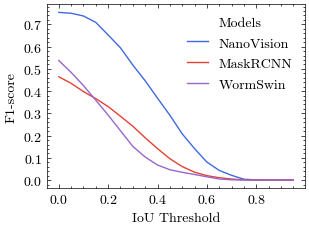

Saved to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou.svg


In [4]:
save_path = OUTPUTS["scoring"] / "f1_vs_iou.svg"

plot_f1_iou_curves(
    df=conf_df,                 
    name_map=F1_NAME_MAP,       
    color_map=COLOR_MAP,
    legend_order=F1_LEGEND_ORDER,
    figsize=FIG_SIZES["double_half"],
    save_path=save_path,
    average='mean_counts',      
)
print("Saved to:", save_path)

# Define model list & metric file (After ablation study)

In [8]:
metric_file = "dsb_per_image_threshold_metrics.csv"

model_names = [
    'fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004',
    'detectron2_trial_1_LB_legacy_recheck',
    'wormswin_20260610',
    'nano1D_20260610',
]

# Load all confusion metrics

In [9]:
NEW_RUN_NAME_MAP = {
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004": "NanoVision",
    "detectron2_trial_1_LB_legacy_recheck": "MaskRCNN",
    "wormswin_20260610": "WormSwin",
    "nano1D_20260610": "Nano1D",
}

NEW_RUN_LEGEND_ORDER = ["NanoVision", "MaskRCNN", "WormSwin"]

conf_df = load_confusion_metrics(
    model_names=model_names,
    project_paths=P,
    metric_file=metric_file,
    metric_subpath="eval/dsb/Diagnostic_eval__gt-chain_none__pred-poly/dsb_per_image_threshold_metrics.csv",
    require_metric_subpath=True,
    legacy_metric_candidates=(),
)

# Map readable model names for the newer run ids.
conf_df["experiment"] = conf_df["experiment"].map(
    lambda x: NEW_RUN_NAME_MAP.get(x, x)
)

# Keep the 3-model comparison only.
conf_df = conf_df[conf_df["experiment"].isin(NEW_RUN_LEGEND_ORDER)]

print(conf_df["experiment"].value_counts(dropna=False))
conf_df.head()


experiment
NanoVision    300
MaskRCNN      300
WormSwin      300
Name: count, dtype: int64


,image_id,IoU_thresh,TP,FP,FN,num_gt_objects,num_pred_objects,avg_dice,dsb_precision,precision,recall,f1_score,fdr,experiment
0,1293-22_3_2_20230306222551,0.05,97,58,7,104,155,0.529024,0.598765,0.625806,0.932692,0.749035,0.374194,NanoVision
1,1293-22_3_2_20230306222551,0.15,95,60,9,104,155,0.529024,0.579268,0.612903,0.913462,0.733591,0.387097,NanoVision
2,1293-22_3_2_20230306222551,0.25,79,76,25,104,155,0.529024,0.438889,0.509677,0.759615,0.610039,0.490323,NanoVision
3,1293-22_3_2_20230306222551,0.35,62,93,42,104,155,0.529024,0.314721,0.400000,0.596154,0.478764,0.600000,NanoVision
4,1293-22_3_2_20230306222551,0.45,39,116,65,104,155,0.529024,0.177273,0.251613,0.375000,0.301158,0.748387,NanoVision


# Plot F1 vs IoU (after ablation)

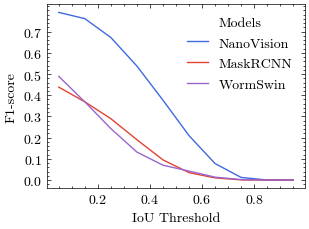

Saved to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou_after_ablation.svg


In [10]:
save_path = OUTPUTS["scoring"] / "f1_vs_iou_after_ablation.svg"

plot_f1_iou_curves(
    df=conf_df,
    name_map=NEW_RUN_NAME_MAP,
    color_map=COLOR_MAP,
    legend_order=NEW_RUN_LEGEND_ORDER,
    figsize=FIG_SIZES["double_half"],
    save_path=save_path,
    average="mean_counts",
)
print("Saved to:", save_path)

In [11]:
f1_at_005 = (
    conf_df[conf_df["IoU_thresh"] == 0.05]
    .groupby("experiment", as_index=True)["f1_score"]
    .mean()
    .sort_index()
    .round(6)
)
print(f1_at_005.to_string())

experiment
MaskRCNN      0.548409
NanoVision    0.809464
WormSwin      0.439752


In [12]:
f1_curve_at_005 = (
    conf_df[conf_df["IoU_thresh"] == 0.05]
    .groupby("experiment")[["TP", "FP", "FN"]]
    .mean()
    .assign(F1=lambda d: 2 * d["TP"] / (2 * d["TP"] + d["FP"] + d["FN"]))
    ["F1"]
    .round(6)
    .sort_index()
)
print(f1_curve_at_005.to_string())

experiment
MaskRCNN      0.438243
NanoVision    0.790711
WormSwin      0.489104


## Method Transparency: Two F1 Averaging Approaches

For each IoU threshold, we report two F1 variants:

1. Per-image mean F1 (`macro` style):
   Compute F1 per image, then average across images.

2. Mean-counts F1 (`mean_counts`):
   Average TP/FP/FN across images first, then compute one F1 from those mean counts.

These are both valid but answer different questions. We plot both for old runs and new runs below.

In [2]:
import pandas as pd

COMPARISON_LEGEND_ORDER = ["NanoVision", "MaskRCNN", "WormSwin"]

OLD_RUNS = ["fluo_new_edt", "detectron2_trial_1", "wormswin"]
OLD_RUN_NAME_MAP = {
    "fluo_new_edt": "NanoVision",
    "detectron2_trial_1": "MaskRCNN",
    "wormswin": "WormSwin",
}

NEW_RUNS = [
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004",
    "detectron2_trial_1_LB_legacy_recheck",
    "wormswin_20260610",
]
NEW_RUN_NAME_MAP = {
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004": "NanoVision",
    "detectron2_trial_1_LB_legacy_recheck": "MaskRCNN",
    "wormswin_20260610": "WormSwin",
}

old_conf_df = load_confusion_metrics(
    model_names=OLD_RUNS,
    project_paths=P,
    metric_file="dsb_per_image_threshold_metrics.csv",
    metric_subpath="eval/dsb/Diagnostic_eval__gt-old__pred-poly/dsb_per_image_threshold_metrics.csv",
    require_metric_subpath=True,
    legacy_metric_candidates=(),
)
old_conf_df["experiment"] = old_conf_df["experiment"].map(lambda x: OLD_RUN_NAME_MAP.get(x, x))
old_conf_df = old_conf_df[old_conf_df["experiment"].isin(COMPARISON_LEGEND_ORDER)].copy()

new_conf_df = load_confusion_metrics(
    model_names=NEW_RUNS,
    project_paths=P,
    metric_file="dsb_per_image_threshold_metrics.csv",
    metric_subpath="eval/dsb/Diagnostic_eval__gt-chain_none__pred-poly/dsb_per_image_threshold_metrics.csv",
    require_metric_subpath=True,
    legacy_metric_candidates=(),
)
new_conf_df["experiment"] = new_conf_df["experiment"].map(lambda x: NEW_RUN_NAME_MAP.get(x, x))
new_conf_df = new_conf_df[new_conf_df["experiment"].isin(COMPARISON_LEGEND_ORDER)].copy()

print("Old runs counts:")
print(old_conf_df["experiment"].value_counts(dropna=False))
print("\nNew runs counts:")
print(new_conf_df["experiment"].value_counts(dropna=False))

Old runs counts:
experiment
NanoVision    600
MaskRCNN      600
WormSwin      560
Name: count, dtype: int64

New runs counts:
experiment
NanoVision    300
MaskRCNN      300
WormSwin      300
Name: count, dtype: int64



Plotting old runs with macro averaging...


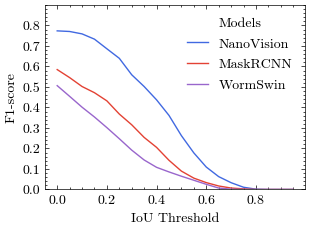

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou_old_macro.svg
Plotting old runs with mean_counts averaging...


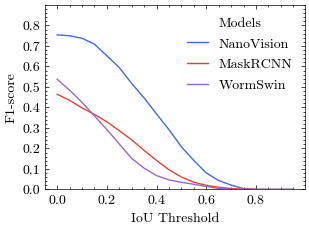

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou_old_mean_counts.svg

Plotting new runs with macro averaging...


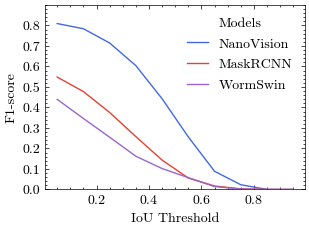

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou_new_macro.svg
Plotting new runs with mean_counts averaging...


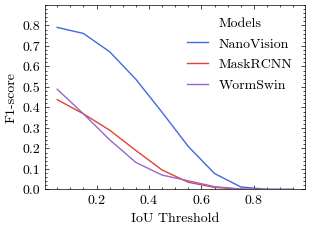

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\f1_vs_iou_new_mean_counts.svg


In [3]:
plot_jobs = [
    ("old", old_conf_df, OLD_RUN_NAME_MAP),
    ("new", new_conf_df, NEW_RUN_NAME_MAP),
]

for tag, df_plot, name_map in plot_jobs:
    macro_path = OUTPUTS["scoring"] / f"f1_vs_iou_{tag}_macro.svg"
    mean_counts_path = OUTPUTS["scoring"] / f"f1_vs_iou_{tag}_mean_counts.svg"

    print(f"\nPlotting {tag} runs with macro averaging...")
    plot_f1_iou_curves(
        df=df_plot,
        name_map=name_map,
        color_map=COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=macro_path,
        average="macro",
    )
    print(f"Saved: {macro_path}")

    print(f"Plotting {tag} runs with mean_counts averaging...")
    plot_f1_iou_curves(
        df=df_plot,
        name_map=name_map,
        color_map=COLOR_MAP,
        legend_order=COMPARISON_LEGEND_ORDER,
        figsize=FIG_SIZES["double_half"],
        save_path=mean_counts_path,
        average="mean_counts",
    )
    print(f"Saved: {mean_counts_path}")

In [16]:
def summarize_iou_005(df_in: pd.DataFrame, split_name: str) -> pd.DataFrame:
    at_005 = df_in[df_in["IoU_thresh"] == 0.05].copy()

    # Macro approach: per-image F1, then mean across images.
    at_005["f1_per_image"] = 2 * at_005["TP"] / (2 * at_005["TP"] + at_005["FP"] + at_005["FN"])
    macro_f1 = (
        at_005.groupby("experiment", as_index=True)["f1_per_image"]
        .mean()
        .rename("macro_f1_at_005")
    )

    # Mean-counts approach: mean TP/FP/FN, then F1 from mean counts.
    mean_counts_f1 = (
        at_005.groupby("experiment")[["TP", "FP", "FN"]]
        .mean()
        .assign(
            mean_counts_f1_at_005=lambda d: 2 * d["TP"] / (2 * d["TP"] + d["FP"] + d["FN"])
        )["mean_counts_f1_at_005"]
    )

    out = pd.concat([macro_f1, mean_counts_f1], axis=1).reset_index()
    out["split"] = split_name
    return out

comparison_005 = pd.concat(
    [
        summarize_iou_005(old_conf_df, "old_runs"),
        summarize_iou_005(new_conf_df, "new_runs"),
    ],
    ignore_index=True,
)[["split", "experiment", "macro_f1_at_005", "mean_counts_f1_at_005"]]

comparison_005 = comparison_005.sort_values(["split", "experiment"]).reset_index(drop=True)
comparison_005.round(6)

,split,experiment,macro_f1_at_005,mean_counts_f1_at_005
0,new_runs,MaskRCNN,0.548409,0.438243
1,new_runs,NanoVision,0.809464,0.790711
2,new_runs,WormSwin,0.439752,0.489104
3,old_runs,MaskRCNN,0.545799,0.434989
4,old_runs,NanoVision,0.770813,0.750070
5,old_runs,WormSwin,0.454361,0.484224
